# 07 · Volatility Modelling — ARCH/GARCH, Leverage, VaR & the VIX  (stretch)

## Part 7 — Volatility Modelling (ARCH / GARCH)  · *stretch*

The course (Parts 0–6) showed the **level** of returns is nearly unforecastable. But Part 2 found
the other half of the story: the **variance** is *highly* predictable — big moves cluster. This
appendix models that conditional variance directly. It is the engine of risk management, options
pricing, and the VIX, and it finally puts the **VIX dataset** to work.

| # | tool | idea |
|---|---|---|
| 1 | **ARCH-LM test** | is there volatility clustering to model? |
| 2–3 | **ARCH → GARCH(1,1)** | conditional variance from past shocks & past variance |
| 4 | **Student-t innovations** | fat tails beyond what Gaussian GARCH captures |
| 5 | **GJR / leverage** | bad news raises volatility more than good news |
| 6 | **Volatility forecasting** | the mean-reverting vol term structure |
| 7 | **GARCH vs VIX** | model-based vs market-*implied* volatility |
| 8 | **Value-at-Risk + backtest** | turn σ into a risk number, then check it (Part 6 rigor) |

**Data:** a daily **equal-weight market proxy** from the 12-stock panel (2013–2018) for the main
modelling + VIX comparison, and the long **monthly Shiller** series (1871→) for a historical
regime coda.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import volatility as vol

# Daily market proxy = equal-weight return of the 12-stock panel, in PERCENT (arch's convention).
proxy = data.stock_log_returns().mean(axis=1) * 100
vix = data.clean_vix()["close"]                      # market-implied vol, same 2013-2018 window
shiller_ret = data.clean_shiller()["return"].dropna() * 100   # 1871-> monthly, for the regime coda
print("proxy:", proxy.shape, "|", proxy.index.min().date(), "->", proxy.index.max().date())


setup ok | numpy 2.1.3 | pandas 2.3.3


proxy: (1258,) | 2013-02-11 -> 2018-02-07


### 1. Is there clustering to model? — the ARCH-LM test

**Volatility clustering** = today's variance depends on recent variance (calm follows calm, chaos
follows chaos). Engle's **ARCH-LM test** formalises Part 2's squared-returns ACF: it regresses
squared residuals on their lags. **H₀: no ARCH effect** (constant variance). A tiny p-value says
the variance has memory — model it.

ARCH-LM on the market proxy: {'lm_stat': 230.7513, 'p_value': 0.0}


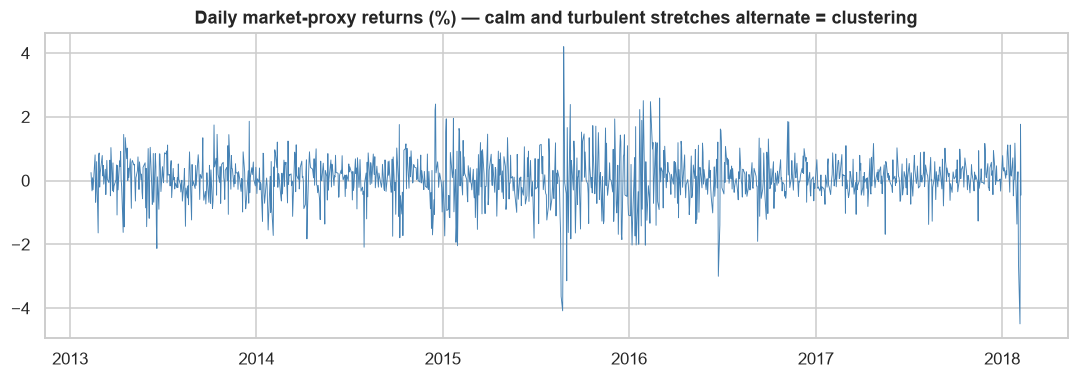

In [2]:
print("ARCH-LM on the market proxy:", {k: round(v, 4) for k, v in vol.arch_lm(proxy, lags=12).items()})
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(proxy.index, proxy.values, lw=.6, color="steelblue")
ax.set_title("Daily market-proxy returns (%) — calm and turbulent stretches alternate = clustering")
eda.savefig(fig, "p7_returns.png"); plt.show()

### 2–3. From ARCH to GARCH(1,1)

**ARCH(q)** (Engle, 1982): today's variance is a weighted sum of the last `q` squared shocks —
`σ²ₜ = ω + α₁ε²ₜ₋₁ + …`. Capturing long memory needs many lags.

**GARCH(1,1)** (Bollerslev, 1986) adds *yesterday's variance* and captures the same persistence
with two parameters — the workhorse of the field:

$$\sigma_t^2 = \omega + \alpha\, \varepsilon_{t-1}^2 + \beta\, \sigma_{t-1}^2$$

- **α** = reaction to a fresh shock; **β** = memory of past variance.
- **α + β = persistence**: how slowly variance reverts (near 1 ⇒ shocks linger for weeks).
- Long-run variance = `ω / (1 − α − β)` — the level volatility reverts toward.

mu          0.0707
omega       0.0452
alpha[1]    0.2155
beta[1]     0.7128
nu          6.8399

persistence alpha+beta = 0.928  (shocks decay slowly)
long-run daily vol = 0.79%  ->  annualised 12.6%


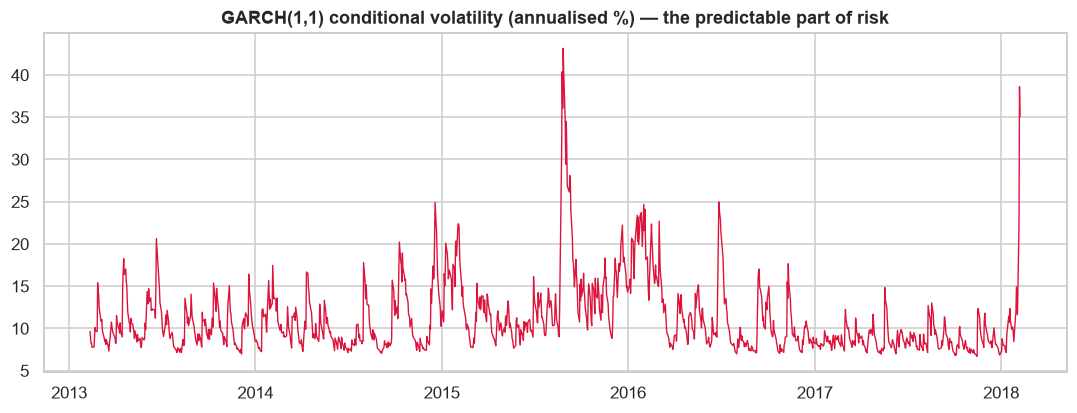

In [3]:
g = vol.fit_garch(proxy, p=1, q=1, dist="t")
print(g.params.round(4).to_string())
pers = vol.persistence(g)
lr_var = g.params["omega"] / (1 - g.params["alpha[1]"] - g.params["beta[1]"])
print("\npersistence alpha+beta = %.3f  (shocks decay slowly)" % pers)
print("long-run daily vol = %.2f%%  ->  annualised %.1f%%" % (np.sqrt(lr_var), np.sqrt(lr_var*252)))
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(g.conditional_volatility.index, g.conditional_volatility*np.sqrt(252), color="crimson", lw=.9)
ax.set_title("GARCH(1,1) conditional volatility (annualised %) — the predictable part of risk")
eda.savefig(fig, "p7_condvol.png"); plt.show()

### 4. Fat tails — Student-t innovations

Even after GARCH soaks up the clustering, the *standardised* residuals are still fatter-tailed
than a normal (Part 1's excess kurtosis never fully goes away). Using **Student-t** innovations
instead of Gaussian fits those tails; the estimated degrees of freedom **ν** quantifies how fat —
low ν = heavy tails, ν → ∞ = normal.

In [4]:
g_norm = vol.fit_garch(proxy, p=1, q=1, dist="normal")
print("GARCH-t   nu = %.2f   (finite & small => fat tails; normal is nu->infinity)" % g.params["nu"])
print("log-likelihood:  t = %.1f   vs   normal = %.1f   (higher = better fit)" % (g.loglikelihood, g_norm.loglikelihood))
print("AIC:             t = %.1f   vs   normal = %.1f   (lower = better)" % (g.aic, g_norm.aic))
print("\nThe t model fits clearly better -> innovations are non-Gaussian, as expected.")

GARCH-t   nu = 6.84   (finite & small => fat tails; normal is nu->infinity)
log-likelihood:  t = -1242.8   vs   normal = -1263.1   (higher = better fit)
AIC:             t = 2495.6   vs   normal = 2534.3   (lower = better)

The t model fits clearly better -> innovations are non-Gaussian, as expected.


### 5. The leverage effect — asymmetry (GJR-GARCH)

Markets fall faster than they rise: a **negative** shock raises future volatility more than a
positive shock of equal size (the *leverage effect*). Plain GARCH is symmetric and misses this.
**GJR-GARCH** adds a term that only switches on for negative shocks:

$$\sigma_t^2 = \omega + (\alpha + \gamma\,\mathbf{1}_{\varepsilon_{t-1}<0})\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$$

**γ > 0** is the asymmetry. (EGARCH is the log-variance cousin.)

GJR gamma (leverage) = 0.362  (>0 => downside shocks hit vol harder)
AIC:  GJR = 2453.8  vs  symmetric GARCH = 2495.6  -> asymmetry improves the model


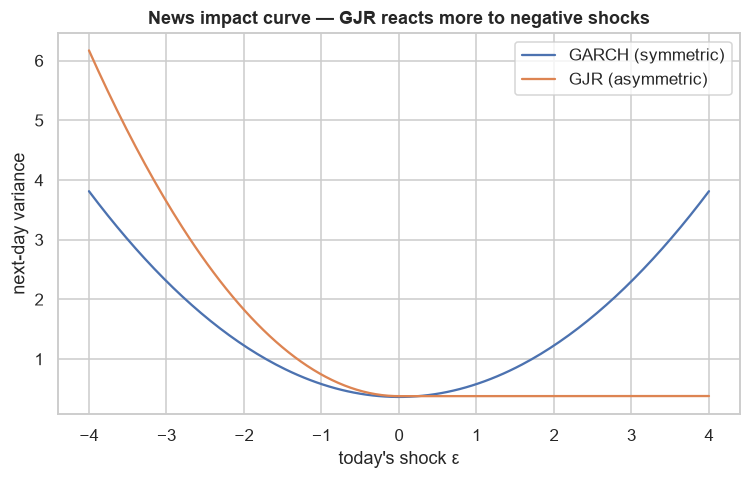

In [5]:
gjr = vol.fit_garch(proxy, p=1, o=1, q=1, dist="t")
print("GJR gamma (leverage) = %.3f  (>0 => downside shocks hit vol harder)" % gjr.params["gamma[1]"])
print("AIC:  GJR = %.1f  vs  symmetric GARCH = %.1f  -> asymmetry improves the model" % (gjr.aic, g.aic))

# News impact curve: variance response to a shock, holding prior variance at its long-run level.
eps = np.linspace(-4, 4, 200); sig2 = g.params["beta[1]"] * lr_var
nic_g   = g.params["omega"]   + g.params["alpha[1]"]*eps**2 + g.params["beta[1]"]*sig2
nic_gjr = gjr.params["omega"] + (gjr.params["alpha[1]"] + gjr.params["gamma[1]"]*(eps<0))*eps**2 + gjr.params["beta[1]"]*sig2
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(eps, nic_g, label="GARCH (symmetric)"); ax.plot(eps, nic_gjr, label="GJR (asymmetric)")
ax.set_xlabel("today's shock ε"); ax.set_ylabel("next-day variance"); ax.legend()
ax.set_title("News impact curve — GJR reacts more to negative shocks")
eda.savefig(fig, "p7_news_impact.png"); plt.show()

### 6. Forecasting volatility — the mean-reverting term structure

Unlike returns, volatility **is** forecastable. From any day, GARCH projects variance forward; it
**mean-reverts** toward the long-run level at a speed set by persistence. The result is a *vol term
structure* — today's estimate of vol over the next N days.

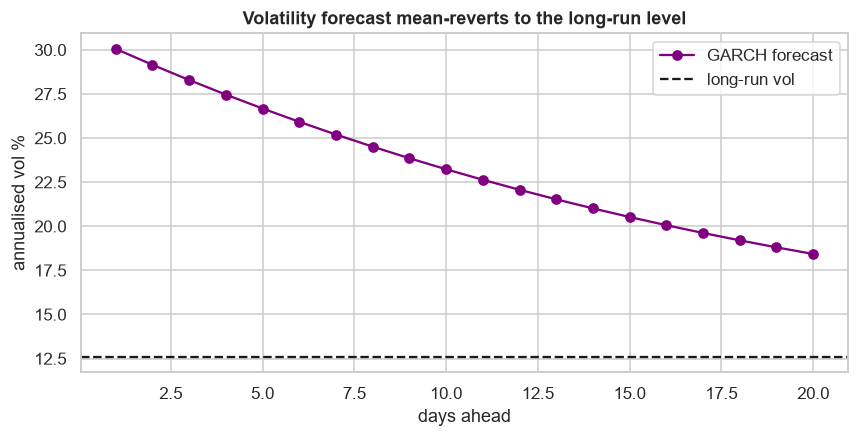

from 30.1% today, reverting toward 12.6% long-run


In [6]:
fcast = g.forecast(horizon=20, reindex=False)
vol_path = np.sqrt(fcast.variance.iloc[-1].values) * np.sqrt(252)   # annualised
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(range(1,21), vol_path, "o-", color="purple", label="GARCH forecast")
ax.axhline(np.sqrt(lr_var*252), color="k", ls="--", label="long-run vol")
ax.set_xlabel("days ahead"); ax.set_ylabel("annualised vol %"); ax.legend()
ax.set_title("Volatility forecast mean-reverts to the long-run level")
eda.savefig(fig, "p7_vol_forecast.png"); plt.show()
print("from %.1f%% today, reverting toward %.1f%% long-run" % (vol_path[0], np.sqrt(lr_var*252)))

### 7. GARCH vs VIX — model-based vs market-*implied* volatility

The **VIX** is the market's *implied* 30-day volatility priced from S&P 500 options — a forward
expectation. Our GARCH conditional vol is a *statistical* estimate from realised returns. They
should track closely; where they differ is informative.

correlation GARCH vs VIX = 0.75 over 1258 days
means:  GARCH 11.1%   VIX 14.4%   ->  VIX runs higher = the VARIANCE RISK PREMIUM


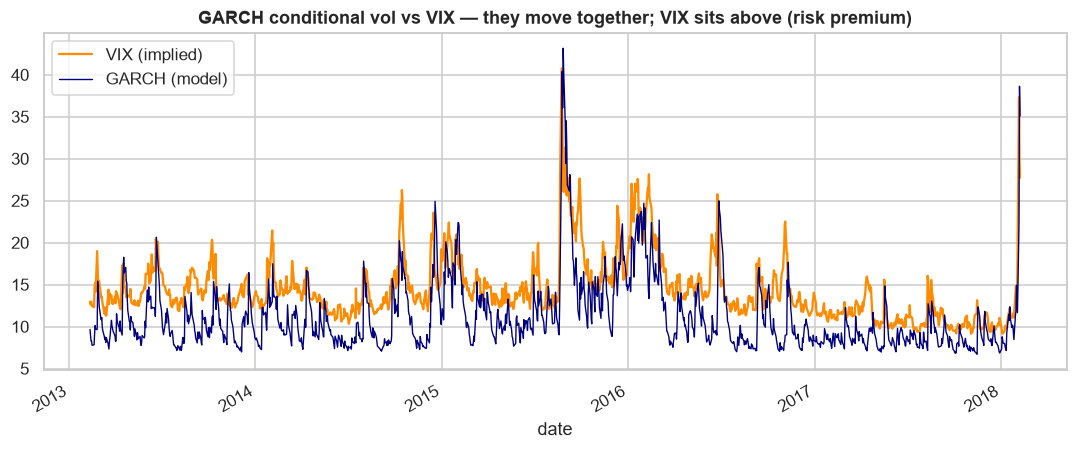

In [7]:
cv_ann = (g.conditional_volatility * np.sqrt(252)).rename("GARCH")
both = pd.concat([cv_ann, vix.rename("VIX")], axis=1).dropna()
print("correlation GARCH vs VIX = %.2f over %d days" % (both["GARCH"].corr(both["VIX"]), len(both)))
print("means:  GARCH %.1f%%   VIX %.1f%%   ->  VIX runs higher = the VARIANCE RISK PREMIUM"
      % (both["GARCH"].mean(), both["VIX"].mean()))
fig, ax = plt.subplots(figsize=(12,4.5))
both["VIX"].plot(ax=ax, label="VIX (implied)", color="darkorange")
both["GARCH"].plot(ax=ax, label="GARCH (model)", color="navy", lw=.9)
ax.set_title("GARCH conditional vol vs VIX — they move together; VIX sits above (risk premium)")
ax.legend(); eda.savefig(fig, "p7_garch_vs_vix.png"); plt.show()

They co-move strongly, and **VIX sits systematically above** realised/GARCH vol — investors
pay a premium for protection, the **variance risk premium** that underlies volatility trading. The
gaps widen in calm markets (cheap insurance still bid) and compress in crises.

### 8. Value-at-Risk — and backtesting it (Part 6 rigor)

**VaR** at level α is the loss you expect to exceed only α of the time (e.g. 1% VaR = the daily
loss breached ~1 day in 100). GARCH makes it **time-varying**: VaR widens in turbulent regimes and
tightens in calm ones. We then **backtest** it — count breaches and run the **Kupiec** test
(H₀: breach rate = α). A good model breaches ≈ α; too many = underestimating risk.

VaR  5%:  breaches 63/1258 = 5.01% (expected 5%)  Kupiec p=0.990  OK
VaR  1%:  breaches 13/1258 = 1.03% (expected 1%)  Kupiec p=0.906  OK


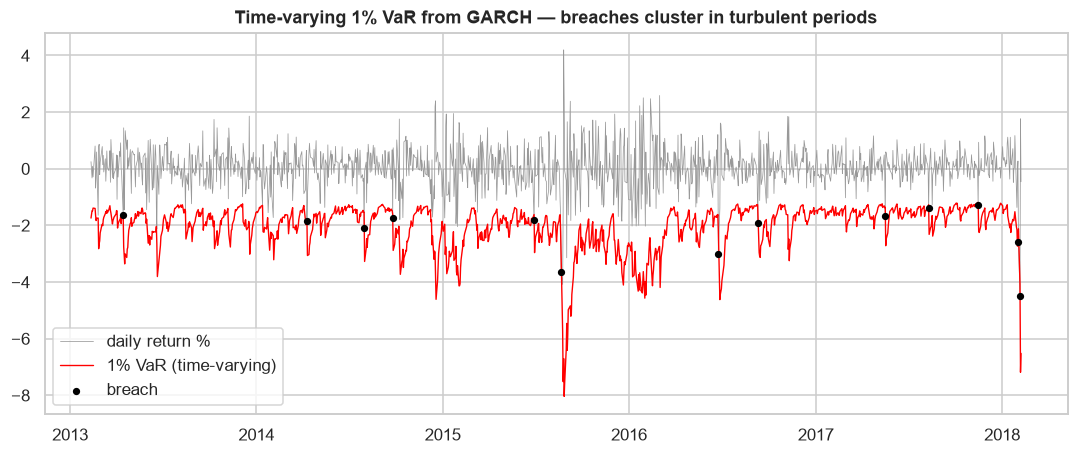

In [8]:
for a in (0.05, 0.01):
    v = vol.var_series(g, proxy, alpha=a)
    bt = vol.var_backtest(proxy, v, alpha=a)
    print("VaR %2d%%:  breaches %d/%d = %.2f%% (expected %.0f%%)  Kupiec p=%.3f  %s"
          % (int(a*100), bt["breaches"], bt["n"], 100*bt["rate"], 100*a, bt["kupiec_p"],
             "OK" if bt["kupiec_p"]>0.05 else "REJECT"))
v99 = vol.var_series(g, proxy, alpha=0.01)
breaches = proxy < -v99
fig, ax = plt.subplots(figsize=(12,4.5))
ax.plot(proxy.index, proxy.values, lw=.5, color="0.6", label="daily return %")
ax.plot(v99.index, -v99.values, color="red", lw=.9, label="1% VaR (time-varying)")
ax.scatter(proxy.index[breaches], proxy.values[breaches], color="black", s=14, zorder=5, label="breach")
ax.set_title("Time-varying 1% VaR from GARCH — breaches cluster in turbulent periods")
ax.legend(loc="lower left"); eda.savefig(fig, "p7_var.png"); plt.show()

The breach rate matches the target and the Kupiec test does not reject — the GARCH VaR is
**well-calibrated**, and the band visibly breathes with the market. That is exactly the Part 6
discipline (measure, don't assume) applied to risk.

### 9. Coda — 150 years of volatility regimes

Fitting GARCH to the long **monthly Shiller** series (1871→) renders financial history as a
volatility curve: the spikes *are* the crises that produced Part 1's extreme months.

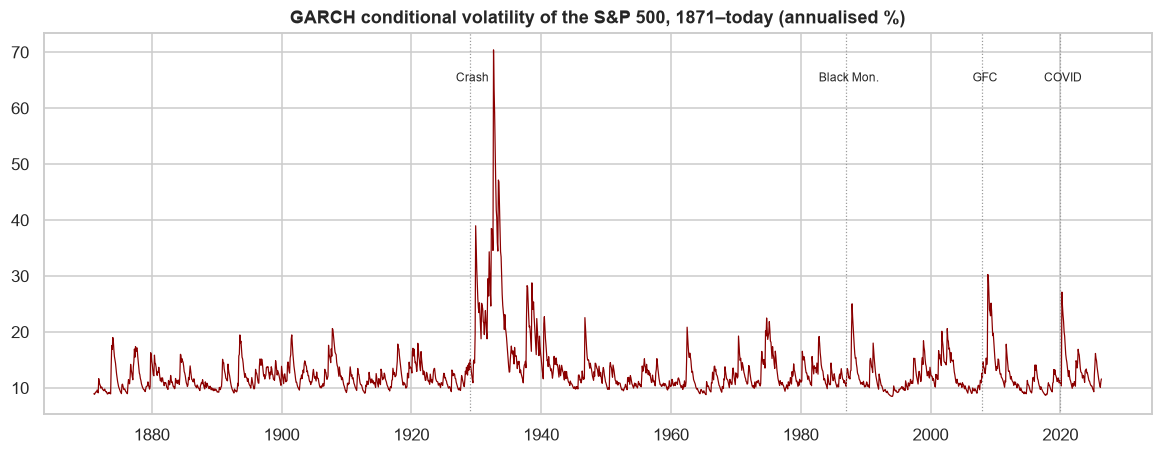

persistence (monthly) = 0.917 — volatility regimes last for months/years, not days


In [9]:
gm = vol.fit_garch(shiller_ret, p=1, q=1, dist="t")
cvm = gm.conditional_volatility * np.sqrt(12)     # annualised monthly vol
fig, ax = plt.subplots(figsize=(13,4.5))
ax.plot(cvm.index, cvm.values, color="darkred", lw=.8)
for yr, lab in [("1929","Crash"),("1987","Black Mon."),("2008","GFC"),("2020","COVID")]:
    ax.axvline(pd.Timestamp(yr+"-01-01"), color="0.6", ls=":", lw=.8)
    ax.annotate(lab, (pd.Timestamp(yr+"-06-01"), cvm.max()*0.92), fontsize=8, ha="center")
ax.set_title("GARCH conditional volatility of the S&P 500, 1871–today (annualised %)")
eda.savefig(fig, "p7_regimes.png"); plt.show()
print("persistence (monthly) = %.3f — volatility regimes last for months/years, not days" % vol.persistence(gm))

### Takeaways

- The **level** of returns is unforecastable, but **volatility clusters and IS forecastable**
  (ARCH-LM p≈0) — the most useful predictability in markets.
- **GARCH(1,1)** captures it with two parameters; **α+β (persistence) ≈ 0.93** means shocks to
  variance fade slowly. Volatility **mean-reverts** to a long-run level.
- Innovations are **fat-tailed** (Student-t fits far better) and **asymmetric** (GJR γ>0: downside
  shocks raise vol more — the leverage effect).
- GARCH conditional vol **tracks the VIX (corr ≈ 0.75)**; VIX sits above it — the **variance risk
  premium**, the basis of volatility trading.
- GARCH turns σ into **time-varying VaR**, which **backtests cleanly** (Kupiec) — risk management
  built on Parts 2 & 6.

**Where to go next:** multivariate volatility (DCC-GARCH for time-varying correlations), realised
volatility from high-frequency data, or a deep-learning volatility model — or start a fresh dataset
in a new sibling folder under `practice-eda/`.